In [ ]:
import pickle
import time
import warnings

warnings.filterwarnings('ignore')

from scipy.optimize import minimize
import numpy as np

from prospect.sources import SSPBasis

from prospect.fitting import lnprobfn
from prospect.models import priors as PRIORS
from prospect.models.sedmodel import HyperSpecModel
from prospect.models.templates import adjust_stochastic_params as _adjust_orig

import hubersed.fitting.chi2 as C
import hubersed.fitting.config as CFG
from hubersed.prospector import parameter_file as P


C_KMS = 299792.458 
TID = 39633140817331167 # quiescent outlier

In [2]:
# function to change the mean of the stocahstic SFH
def patch_ratio_prior(mean_vec):
    def adjusted(parset, tuniv=13.7):
        parset = _adjust_orig(parset, tuniv)
        pr = parset['logsfr_ratios']['prior']
        mu = (np.zeros(len(pr.params['mean'])) if mean_vec is None else np.asarray(mean_vec, float))
        pr.params['mean'] = mu
        parset['logsfr_ratios']['init'] = mu.copy()
        return parset

    CFG.adjust_stochastic_params = adjusted

In [3]:
gidx = int(C.tids_to_indices(np.asarray([TID], dtype=np.int64))[0])
spec, ivar, z, tid_chunk = C.load_by_index(gidx)
assert tid_chunk == TID, f"Loaded TID {tid_chunk} does not match requested TID {TID}"

flux = C.flambda_to_maggies(C.WAVE_OBS, spec)
ivm = C.ivar_flambda_to_ivar_maggies(C.WAVE_OBS, ivar)
good = (ivm > 0) & (flux > 0) & np.isfinite(flux)
unc  = 1/np.sqrt(np.where(ivm > 0, ivm, np.inf))

sps = C._fsps()
fw = sps.ssp.emline_wavelengths
fopt = fw[(fw > 3600) & (fw < 9824)]
# mask = P.mask_spectral_lines(C.WAVE_OBS, good, z, halfwidth_kms=1500.0, line_waves=fopt)
mask = good

sig_desi  = C._lsf_sigma_kms()
sig_miles = C_KMS * 2.54 / 2.355 / (C.WAVE_OBS / (1 + z))          # MILES 2.54A FWHM, rest
sig_extra = np.maximum(np.sqrt(np.clip(sig_desi**2 - sig_miles**2, 0, None)), 5.0)  # 5 km/s floor for the LSF FFT

obs = P.build_obs(spec=flux, unc=unc, mask=mask,
                  resolution=sig_desi, wavelength=np.asarray(C.WAVE_OBS, float))
print(f"gidx {gidx}  z={z:.4f}  fitted px: {mask.sum()}")

Loading calibrated DESI resolution from resolution matrices...
gidx 42580  z=0.0187  fitted px: 5840


In [4]:
def optimize_multi(model, n_seeds=16, maxfev=3000, state={}, rng_seed=11, frac=0.05):
    lo, hi = zip(*model.theta_bounds())
    lo, hi = np.array(lo, float), np.array(hi, float)
    span = np.where(np.isfinite(hi - lo), hi - lo, 1.0)
    eps = 1e-9 * np.maximum(span, 1e-9)

    def neg(th):
        try:
            lp = lnprobfn(th, model=model, observations=obs, sps=sps, nested=False)
            return -lp if np.isfinite(lp) else 1e18
        except Exception:
            return 1e18

    def alive_start(center, scale, rng):
        for _ in range(50):                      # resample until finite
            x0 = np.clip(center + rng.normal(0, scale*span, len(center)),
                         lo + eps, hi - eps)
            if neg(x0) < 1e17:
                return x0
        return np.clip(center, lo + eps, hi - eps)

    best_x, best_f, s = state.get("x"), state.get("f", np.inf), state.get("s", 0)
    rng = np.random.default_rng(rng_seed + s)    # fresh stream on resume
    th0 = np.clip(model.theta.copy(), lo + eps, hi - eps)
    while s < n_seeds:
        if s == 0 or best_x is None:
            x0 = th0
        elif s % 3 == 2:
            x0 = alive_start(th0, 4*frac, rng)   # wide restart
        else:
            x0 = alive_start(best_x, frac, rng)  # local restart
        r = minimize(neg, x0, method="Powell",
                     options=dict(maxfev=maxfev, xtol=1e-4, ftol=1e-6))
        if r.fun < best_f: best_f, best_x = float(r.fun), r.x.copy()
        s += 1
        state.update(x=best_x, f=best_f, s=s)
        print(f"seed {s}: this {r.fun:.1f}  best {best_f:.1f}")
    return best_x

def chi2_of(model, x):
    preds, _ = model.predict(x, observations=obs, sps=sps)
    m = obs[0].mask
    chi2 = float(np.nansum(((obs[0].flux[m]-preds[0][m])/obs[0].uncertainty[m])**2))
    return chi2/m.sum(), preds[0]

In [5]:
# first run (A): mean zero prior
patch_ratio_prior(mean_vec=None)

cmodelA, ctempA = CFG.build_continuum_model(z)
stateAc = {}
cxA = optimize_multi(cmodelA, n_seeds=2, state=stateAc)

fmodelA, _ = CFG.build_full_model(ctempA, cxA, cmodelA, z)
stateA = {} 
xA = optimize_multi(fmodelA, n_seeds=16, state=stateA, maxfev=120_000)

chiA, specA = chi2_of(fmodelA, xA)
tdA = {k: np.asarray(xA[v]) for k, v in fmodelA.theta_index.items()}
print(f"A: chi2/px = {chiA:.3f}   logzsol {float(tdA['logzsol'][0]):+.2f}")

seed 1: this -65104.6  best -65104.6
seed 2: this -77201.2  best -77201.2
seed 1: this -88944.8  best -88944.8
seed 2: this -64367.9  best -88944.8
seed 3: this -82448.5  best -88944.8
seed 4: this -88435.5  best -88944.8
seed 5: this -86756.9  best -88944.8
seed 6: this 20447.3  best -88944.8
seed 7: this -41049.7  best -88944.8
seed 8: this -89513.7  best -89513.7
seed 9: this -88222.6  best -89513.7
seed 10: this -90455.4  best -90455.4
seed 11: this -90717.2  best -90717.2
seed 12: this -83902.9  best -90717.2
seed 13: this -85269.0  best -90717.2
seed 14: this -90720.7  best -90720.7
seed 15: this -88345.7  best -90720.7
seed 16: this -51400.6  best -90720.7
A: chi2/px = 4.475   logzsol +0.25


In [6]:
# arm B would be a different mean where we have two branches for quenching
import importlib.util
from hubersed.paths import PATHS

_s = importlib.util.spec_from_file_location("pilot_tb", PATHS["ROOT"] / "bin/model_seds/pilot_twobranch_priors.py")
PT = importlib.util.module_from_spec(_s); _s.loader.exec_module(PT)
mu_q = PT.mu_ratios(10.8, z, True, 2.0, 1.0, PT.MseedInverter())   # t_q=2 Gyr, tau_q=1 Gyr, floor 0.75


patch_ratio_prior(mu_q)

cmodelB, ctempB = CFG.build_continuum_model(z)
stateBc = {}
cxB = optimize_multi(cmodelB, n_seeds=2, state=stateBc)

fmodelB, _ = CFG.build_full_model(ctempB, cxB, cmodelB, z)
stateB = {}
xB = optimize_multi(fmodelB, n_seeds=16, state=stateB, maxfev=120_000)

chiB, specB = chi2_of(fmodelB, xB)
tdB = {k: np.asarray(xB[v]) for k, v in fmodelB.theta_index.items()}
print(f"B: chi2/px = {chiB:.3f}   logzsol {float(tdB['logzsol'][0]):+.2f}")

seed 1: this -86778.7  best -86778.7
seed 2: this -63616.6  best -86778.7
seed 1: this -90135.1  best -90135.1
seed 2: this -83734.8  best -90135.1
seed 3: this -90343.6  best -90343.6
seed 4: this -90303.6  best -90343.6
seed 5: this -90496.6  best -90496.6
seed 6: this 59820.5  best -90496.6
seed 7: this -55202.2  best -90496.6
seed 8: this -87356.6  best -90496.6
seed 9: this -85838.8  best -90496.6
seed 10: this -90590.5  best -90590.5
seed 11: this -89746.9  best -90590.5
seed 12: this -75675.3  best -90590.5
seed 13: this -55163.7  best -90590.5
seed 14: this -90570.1  best -90590.5
seed 15: this -86465.1  best -90590.5
seed 16: this -53922.0  best -90590.5
B: chi2/px = 4.523   logzsol +0.25


In [7]:
# Arm C or third run would be a full free SFH
patch_ratio_prior(None)
cmodelC, ctempC = CFG.build_continuum_model(z)

_, ftempC = CFG.build_full_model(ctempC, cmodelC.theta.copy(), cmodelC, z)

for k in list(ftempC.keys()):
    if not isinstance(ftempC[k], dict) or "isfree" not in ftempC[k]: continue
    if k in tdB:
        v = np.asarray(tdB[k], float).ravel()
        ftempC[k]["init"] = v if v.size > 1 else float(v[0])
    ftempC[k]["isfree"] = k in ("logmass", "logsfr_ratios")
ftempC["logsfr_ratios"]["prior"] = PRIORS.TopHat(mini=-8.0, maxi=8.0)
ftempC["logmass"]["prior"] = PRIORS.TopHat(mini=8.0, maxi=12.5)
modelC = HyperSpecModel(configuration=ftempC)

stateC = {}
xC = optimize_multi(modelC, n_seeds=24, maxfev=120_000, state=stateC)

chiC, specC = chi2_of(modelC, xC)
ti = modelC.theta_index
print(f"C: chi2/px = {chiC:.3f}   ratios {np.round(xC[ti['logsfr_ratios']],2)}")

seed 1: this -90609.2  best -90609.2
seed 2: this -90659.3  best -90659.3
seed 3: this -90469.6  best -90659.3
seed 4: this -90648.8  best -90659.3
seed 5: this -90672.3  best -90672.3
seed 6: this -90670.3  best -90672.3
seed 7: this -90679.0  best -90679.0
seed 8: this -90677.7  best -90679.0
seed 9: this -90668.4  best -90679.0
seed 10: this -90669.4  best -90679.0
seed 11: this -90678.9  best -90679.0
seed 12: this -80206.1  best -90679.0
seed 13: this -80216.3  best -90679.0
seed 14: this -90673.2  best -90679.0
seed 15: this -90656.2  best -90679.0
seed 16: this -90668.3  best -90679.0
seed 17: this -89487.9  best -90679.0
seed 18: this -90574.2  best -90679.0
seed 19: this -90674.3  best -90679.0
seed 20: this -90658.0  best -90679.0
seed 21: this -90553.0  best -90679.0
seed 22: this -90672.8  best -90679.0
seed 23: this -90673.8  best -90679.0
seed 24: this -90493.8  best -90679.0
C: chi2/px = 4.498   ratios [ 0.63  1.26  2.77 -2.58  1.21 -1.27 -3.93  0.34 -0.53]


In [13]:
import pickle, subprocess, time
from pathlib import Path
from hubersed.paths import PATHS

def sha(repo):
    try: return subprocess.run(["git","-C",str(repo),"rev-parse","--short","HEAD"],
                               capture_output=True,text=True).stdout.strip()
    except Exception: return "unknown"

OUT = PATHS["RESULTS"] / "map_native"; OUT.mkdir(parents=True, exist_ok=True)

def save_arm(arm, model, x, state, chi_px, spec, extra=None):
    preds_mask = np.asarray(obs[0].mask)
    rec = dict(
        tid=TID, gidx=gidx, z=float(z), arm=arm,
        chi2_px=float(chi_px), npix=int(preds_mask.sum()),
        seeds=int(state.get("s", -1)), neg_lnp=float(state.get("f", np.nan)),
        theta=np.asarray(x), labels=list(model.free_params),
        theta_dict={k: np.asarray(x[v]) for k, v in model.theta_index.items()},
        model_spec=np.asarray(spec, np.float32), mask=preds_mask,
        # --- provenance ---
        config=dict(resolution="sig_desi_full_no_subtraction", line_mask="none (ivar only)",
                    maxfev=120000, optimizer="Powell bounds-aware v2",
                    quench=dict(tq=2.0, tauq=1.0, floor=0.75) if arm=="B" else None),
        # hubersed_sha=sha(PATHS["ROOT"]),
        # prospector_sha=sha(Path.home()/"Astronomy_Research/prospector"),
        when=time.strftime("%Y-%m-%d %H:%M"),
        versions={m.__name__: getattr(m, "__version__", "?")
                  for m in (np, __import__("scipy"), __import__("fsps"), __import__("prospect"))},
        **(extra or {}),
    )
    p = OUT / f"{TID}_{arm}_nomask_native.pkl"
    pickle.dump(rec, open(p, "wb"))
    print("saved", p)

# after each arm finishes:
save_arm("A", fmodelA, xA, stateA, chiA, specA)
save_arm("B", fmodelB, xB, stateB, chiB, specB)
save_arm("C", modelC,  xC, stateC, chiC, specC)

saved /Users/ng27753/Astronomy_Research/hubersed/results/map_native/39633140817331167_A_nomask_native.pkl
saved /Users/ng27753/Astronomy_Research/hubersed/results/map_native/39633140817331167_B_nomask_native.pkl
saved /Users/ng27753/Astronomy_Research/hubersed/results/map_native/39633140817331167_C_nomask_native.pkl


In [8]:
w = C.WAVE_OBS / (1 + z); m = obs[0].mask
regions = [("blue <4500", 3540, 4500), ("Mgb/Fe 4500-5100", 4500, 5100),
           ("NaD 5100-5950", 5100, 5950), ("5950-6400", 5950, 6400),
           ("bump 6400-7100", 6400, 7100), ("7100-7490", 7100, 7490),
           (">7490 ceiling", 7490, 9700)]
print(f"{'region':20s}{'npix':>6s}{'A':>8s}{'B':>8s}{'C':>8s}")
for nm, lo, hi in regions:
    s = m & (w >= lo) & (w < hi)
    if s.sum() < 10: continue
    row = f"{nm:20s}{s.sum():6d}"
    for sp_ in (specA, specB, specC):
        row += f"{np.nansum(((obs[0].flux[s]-sp_[s])/obs[0].uncertainty[s])**2)/s.sum():8.2f}"
    print(row)

region                npix       A       B       C
blue <4500            1223    2.14    2.23    2.33
Mgb/Fe 4500-5100       764    2.66    2.96    2.80
NaD 5100-5950          997    3.93    4.36    3.97
5950-6400              503    3.43    3.45    3.58
bump 6400-7100         804    5.70    5.44    5.43
7100-7490              293    5.44    5.42    5.41
>7490 ceiling         1248    7.74    7.51    7.67


In [9]:
def param_report(model, x, name):
    print(f"\n=== {name} ===")
    for k, inds in model.theta_index.items():
        vals = np.atleast_1d(x[inds])
        pr = model.config_dict[k]["prior"]
        try:    lo, hi = pr.bounds()
        except Exception: lo, hi = -np.inf, np.inf
        lo, hi = np.atleast_1d(lo), np.atleast_1d(hi)
        flags = []
        for i, v in enumerate(vals):
            l = lo[min(i, len(lo)-1)]; h = hi[min(i, len(hi)-1)]
            if np.isfinite(l) and np.isfinite(h):
                w = h - l
                if v - l < 0.02*w: flags.append("AT-LOWER")
                elif h - v < 0.02*w: flags.append("AT-UPPER")
        tag = " <-- " + ",".join(flags) if flags else ""
        print(f"  {k:16s} {np.round(vals,3)}{tag}")

param_report(fmodelA, xA, "arm A")
param_report(fmodelB, xB, "arm B")
param_report(modelC,  xC, "arm C (free)")


=== arm A ===
  logzsol          [0.25]
  dust2            [0.132]
  logmass          [9.991]
  sigma_reg        [5.] <-- AT-UPPER
  tau_eq           [0.01] <-- AT-LOWER
  tau_in           [0.01] <-- AT-LOWER
  sigma_dyn        [0.001] <-- AT-LOWER
  tau_dyn          [0.01]
  logsfr_ratios    [ 6.589e+00  4.714e+00 -4.000e+00 -1.640e-01 -2.018e+00 -1.583e+00
 -5.187e+00 -3.760e-01  4.000e-03]
  dust_ratio       [0.871]
  dust_index       [-2.324]
  sigma_smooth     [151.332]
  gas_logz         [0.328]
  gas_logu         [-3.404]
  eline_sigma      [250.] <-- AT-UPPER

=== arm B ===
  logzsol          [0.25]
  dust2            [0.152]
  logmass          [9.894]
  sigma_reg        [3.325]
  tau_eq           [0.08] <-- AT-LOWER
  tau_in           [0.01] <-- AT-LOWER
  sigma_dyn        [0.001] <-- AT-LOWER
  tau_dyn          [0.01]
  logsfr_ratios    [ 1.102  1.348  0.632  1.021  2.939 -2.723 -5.213 -1.45   0.976]
  dust_ratio       [0.9]
  dust_index       [-2.214]
  sigma_smooth     [14

min at logzsol = 0.26  edge value: 58.497  min: 4.61


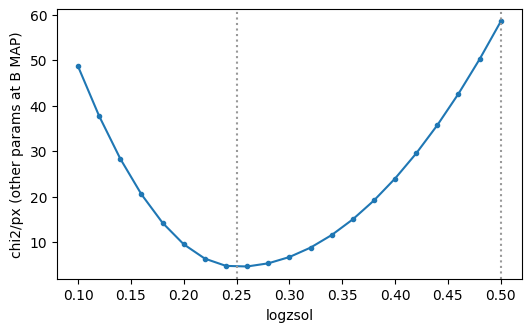

In [10]:
iz = fmodelB.theta_index["logzsol"]
zgrid = np.arange(0.10, 0.501, 0.02)
prof = []
for zz in zgrid:
    t2 = xB.copy(); t2[iz] = zz
    c2, _ = chi2_of(fmodelB, t2)
    prof.append(c2)
prof = np.array(prof)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3.5))
plt.plot(zgrid, prof, ".-"); plt.axvline(0.25, ls=":", c="0.6"); plt.axvline(0.5, ls=":", c="0.6")
plt.xlabel("logzsol"); plt.ylabel("chi2/px (other params at B MAP)")
print("min at logzsol =", zgrid[np.argmin(prof)], " edge value:", prof[-1].round(3), " min:", prof.min().round(3))

In [11]:
xC = optimize_multi(modelC, n_seeds=40, maxfev=120_000, state=stateC)
chiC, specC = chi2_of(modelC, xC)
ti = modelC.theta_index
print(f"C after {stateC['s']} seeds: chi2/px = {chiC:.3f}")
print("ratios:", np.round(xC[ti["logsfr_ratios"]], 2), " logmass:", round(float(xC[ti["logmass"]][0]),3))

seed 25: this -90363.9  best -90679.0
seed 26: this -90674.2  best -90679.0
seed 27: this -90373.8  best -90679.0
seed 28: this -90381.1  best -90679.0
seed 29: this -90271.6  best -90679.0
seed 30: this -80240.8  best -90679.0
seed 31: this -90150.4  best -90679.0
seed 32: this -90648.8  best -90679.0
seed 33: this -80228.4  best -90679.0
seed 34: this -90663.9  best -90679.0
seed 35: this -90674.8  best -90679.0
seed 36: this -90595.3  best -90679.0
seed 37: this -90244.6  best -90679.0
seed 38: this -90670.7  best -90679.0
seed 39: this -85856.3  best -90679.0
seed 40: this -90675.6  best -90679.0
C after 40 seeds: chi2/px = 4.498
ratios: [ 0.63  1.26  2.77 -2.58  1.21 -1.27 -3.93  0.34 -0.53]  logmass: 10.009


Text(0.5, 1.0, 'TID 39633140817331167  z=0.0187')

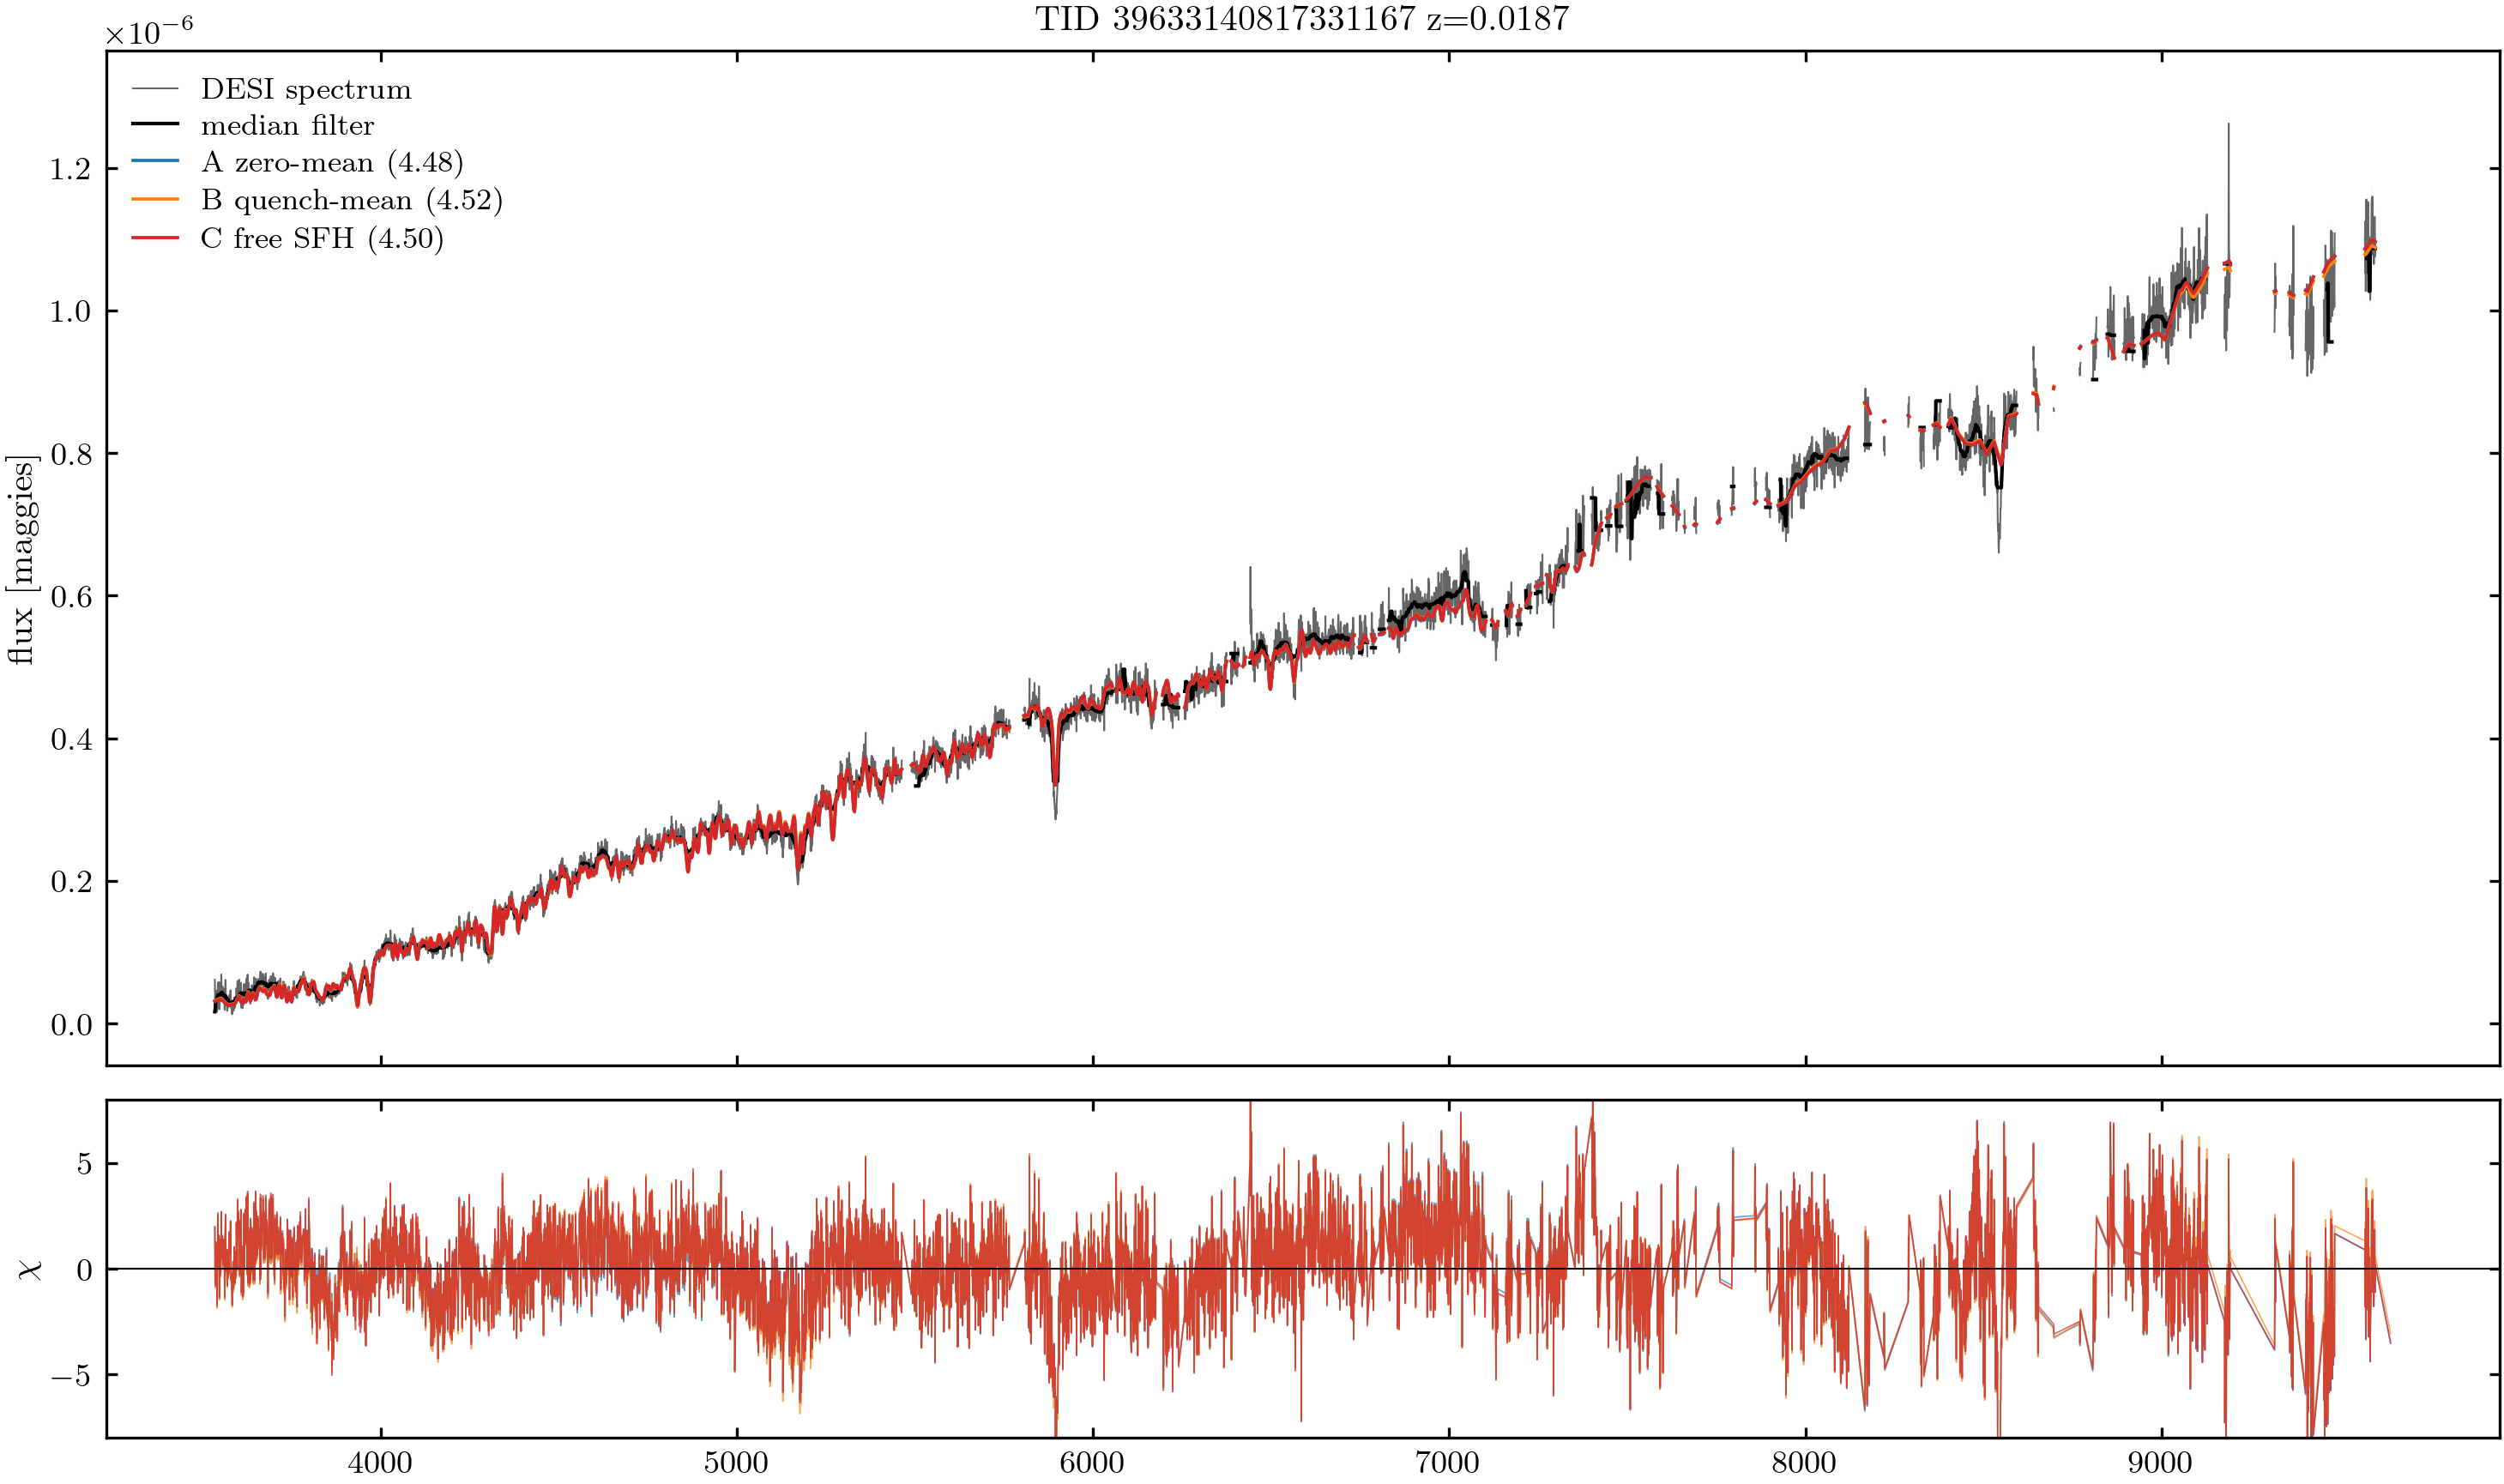

In [30]:
from scipy.signal import medfilt
from hubersed.plotting.spectra import spectrum_figure, residual_chi

m = obs[0].mask; w = C.WAVE_OBS
d  = np.where(m, obs[0].flux, np.nan)
u  = np.where(m, obs[0].uncertainty, np.nan)
mf = np.where(m, medfilt(np.where(m, obs[0].flux, np.nan), 31), np.nan)
# mf = None
fits = [("A zero-mean",   specA, f"{chiA:.2f}", "C0"),
        ("B quench-mean", specB, f"{chiB:.2f}", "C1"),
        ("C free SFH",    specC, f"{chiC:.2f}", "C3")]
fig, ax = spectrum_figure(w, z=z, data=d, unc=u, medfilt=mf, band_kw={},
    models=[{"flux": np.where(m, s, np.nan), "label": f"{nm} ({c2})", "color": col, "lw": 0.9}
            for nm, s, c2, col in fits], figsize=(12, 7))
wr = w / (1 + z)
for nm, s, c2, col in fits:
    chi = residual_chi(obs[0].flux, s, obs[0].uncertainty, mask=m)
    ax[1].plot(wr[m], chi[m], lw=0.4, alpha=0.7, color=col)
ax[1].axhline(0, c="k", lw=0.5); ax[1].set_ylim(-8, 8); ax[1].set_ylabel(r"$\chi$")

ax[0].set_ylabel("flux [maggies]")   # data/models are maggies, not the label default
ax[0].set_title(f"TID {TID}  z={z:.4f}")

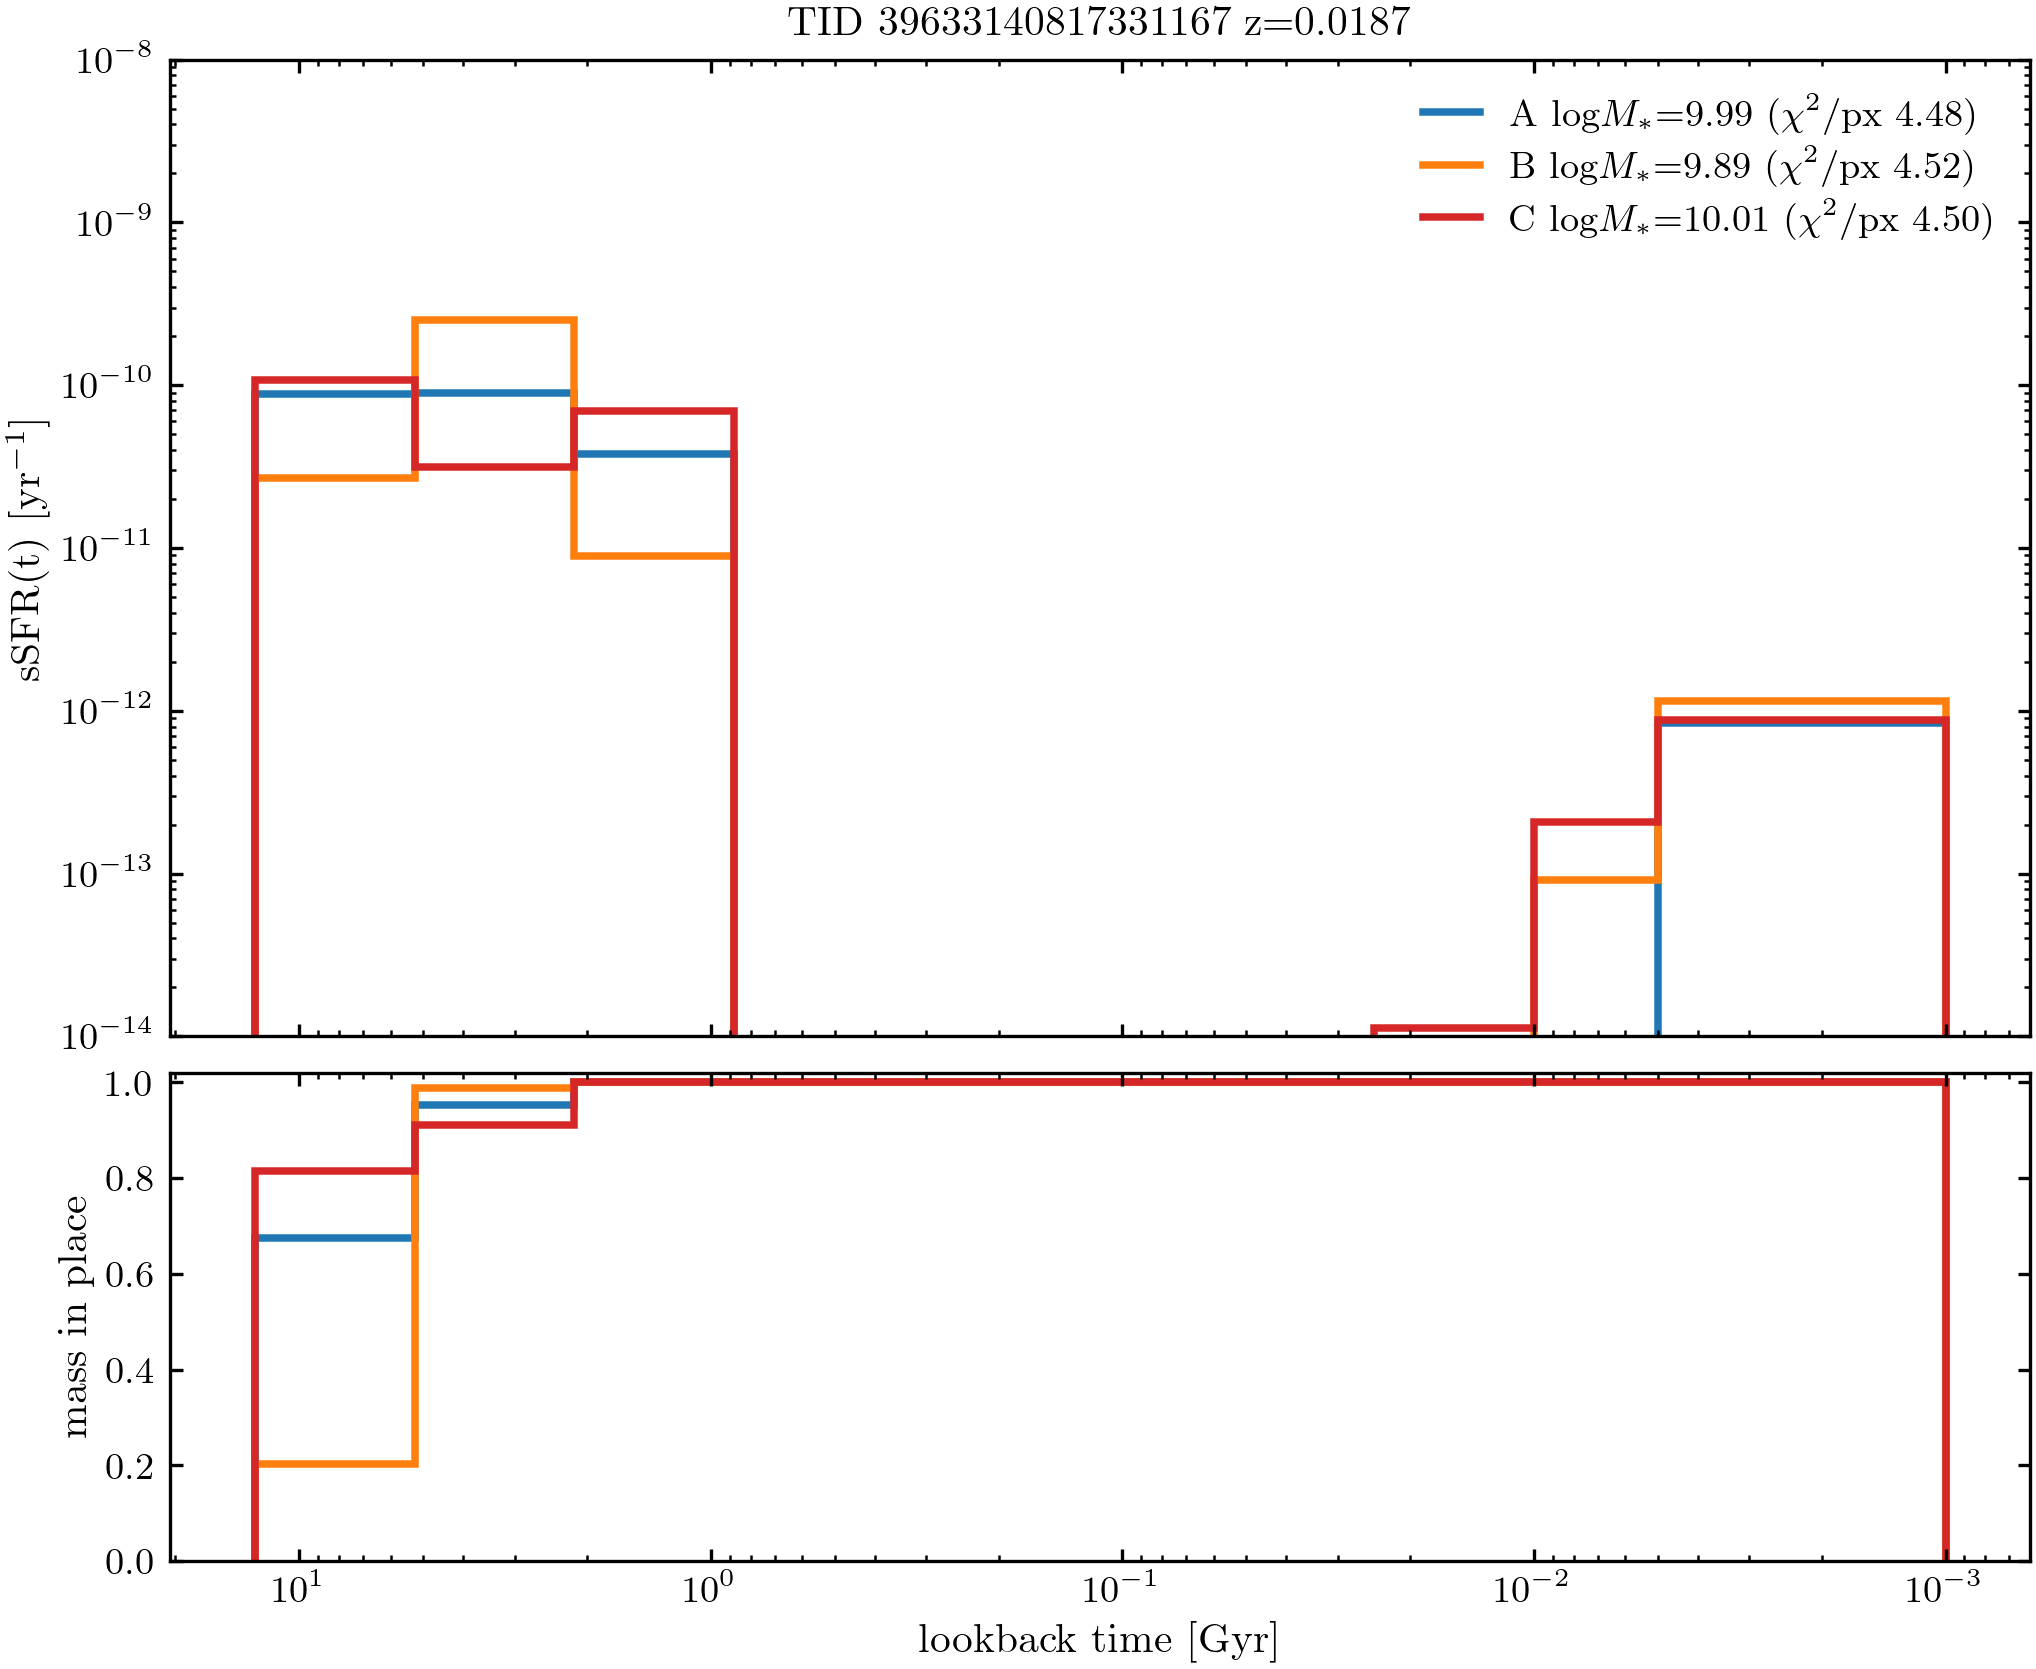

In [22]:
# sSFR(t) + cumulative mass from the saved MAP pickles
import pickle
import numpy as np
import matplotlib.pyplot as plt
from hubersed.paths import PATHS
from hubersed.prospector.utils import make_stochastic_agebins

TID = 39633140817331167
R = {a: pickle.load(open(PATHS["RESULTS"]/"map_native"/f"{TID}_{a}_nomask_native.pkl", "rb"))
     for a in "ABC"}
z = R["A"]["z"]

ab = make_stochastic_agebins(z=z)          # log10(yr) edges, (10, 2)
e = 10**ab / 1e9                            # Gyr
edges = np.concatenate([e[:, 0], [e[-1, 1]]])
dt = (e[:, 1] - e[:, 0]) * 1e9              # yr
bc = e.mean(axis=1)

fig, axs = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})
for arm, col in [("A", "C0"), ("B", "C1"), ("C", "C3")]:
    td = R[arm]["theta_dict"]
    r = np.asarray(td["logsfr_ratios"], float)
    lm = float(np.atleast_1d(td["logmass"])[0])
    sfr = 10**np.concatenate([[0.], -np.cumsum(r)])
    sfr *= 10**lm / np.sum(sfr * dt)                     # normalize to formed mass
    mb = sfr * dt / np.sum(sfr * dt)                     # mass fraction per bin
    axs[0].stairs(sfr / 10**lm, edges, color=col, lw=1.8,
                  label=f"{arm}  log$M_*$={lm:.2f}  ($\\chi^2$/px {R[arm]['chi2_px']:.2f}) ")
                        # f"MWA {np.sum(mb*bc):.1f} Gyr)")
    axs[1].stairs(np.cumsum(mb[::-1])[::-1], edges, color=col, lw=1.8)

axs[0].set_xscale("log"); axs[0].set_yscale("log"); axs[0].set_ylim(1e-14, 1e-8)
axs[0].set_ylabel(r"sSFR(t) [yr$^{-1}$]")
axs[0].legend(fontsize=9, loc="upper right")
axs[0].set_title(f"TID {TID}  z={z:.4f}")
axs[1].set_xscale("log"); axs[1].set_ylim(0, 1.02)
axs[1].set_ylabel("mass in place")
axs[1].set_xlabel("lookback time [Gyr]")
# # left 3 bins: the flat age ridge (MWA spread ~3 Gyr at dchi2/px = 0.05)
# for a in axs:
#     a.axvspan(e[7, 0], e[9, 1], color="0.85", alpha=0.4, zorder=0)
axs[0].invert_xaxis()
fig.savefig(PATHS["RESULTS"]/"map_native"/f"{TID}_ssfr_map.png",
            dpi=150, bbox_inches="tight")

In [23]:
# EXACT any-SFH floor at fixed nuisances: NNLS over per-bin masses
from scipy.optimize import nnls

base = R["A"]  # or "B": the nuisance set to condition on
tdN = base["theta_dict"]

# build the 10 basis spectra: one-hot mass in each bin (tiny floor elsewhere)
def ratios_from_massfrac(mb):
    sfr = np.clip(mb, 1e-12, None) / dt
    return np.log10(sfr[:-1] / sfr[1:])

basis = np.zeros((10, len(C.WAVE_OBS)))
th0 = fmodelA.theta.copy()                       # arm-A model object from earlier cells
for k, v in tdN.items():                         # pin all params at the chosen MAP
    th0[fmodelA.theta_index[k]] = v
ir = fmodelA.theta_index["logsfr_ratios"]
im = fmodelA.theta_index["logmass"]
th0[im] = 10.0                                   # any fixed mass; NNLS rescales
for i in range(10):
    mb = np.full(10, 1e-9); mb[i] = 1.0
    th0[ir] = ratios_from_massfrac(mb)
    preds, _ = fmodelA.predict(th0, observations=obs, sps=sps)
    basis[i] = preds[0]

m = obs[0].mask
A_mat = (basis[:, m] / obs[0].uncertainty[m]).T   # (npix, 10)
b_vec = obs[0].flux[m] / obs[0].uncertainty[m]
coeff, rnorm = nnls(A_mat, b_vec)
chi2_px_nnls = rnorm**2 / m.sum()
mb_best = coeff * 10**10 * dt / np.sum(coeff * 10**10 * dt)   # implied mass fractions
print(f"GLOBAL any-SFH floor (nuisances at {base['arm']}): chi2/px = {chi2_px_nnls:.3f}")
print(f"  (Powell C found 4.498; A found 4.475)")
print("  mass fractions:", np.round(mb_best, 3))
print("  MWA = %.2f Gyr" % np.sum(mb_best * bc))

GLOBAL any-SFH floor (nuisances at A): chi2/px = 4.474
  (Powell C found 4.498; A found 4.475)
  mass fractions: [0.    0.    0.    0.    0.    0.    0.    0.012 0.092 0.896]
  MWA = 8.47 Gyr


In [ ]:
# superposition check: direct predict of a mixed SFH vs mass-weighted basis sum
mb = np.array([0, 0, 0, 0, 0, 0, 0, 0.1, 0.4, 0.5])
th0[ir] = ratios_from_massfrac(mb)
th0[im] = 10.0
direct, _ = fmodelA.predict(th0, observations=obs, sps=sps)

recon = mb @ basis                      # basis rows were unit TOTAL mass each -> weight by mass fraction
err = np.nanmax(np.abs(direct[0][m] - recon[m]) / np.maximum(np.abs(direct[0][m]), 1e-30))
print(f"max fractional superposition error over fitted pixels: {err:.2e}")

max fractional superposition error over fitted pixels: 4.72e-05


In [27]:
# Na D masked: rest 5876-5910 out of the fit; rerun the NNLS floor + report
nad = (C.WAVE_OBS/(1+z) >= 5876) & (C.WAVE_OBS/(1+z) <= 5910)
m2 = obs[0].mask & ~nad
A2 = (basis[:, m2] / obs[0].uncertainty[m2]).T
b2 = obs[0].flux[m2] / obs[0].uncertainty[m2]
c2, rn2 = nnls(A2, b2)
print(f"any-SFH floor, NaD masked: chi2/px = {rn2**2/m2.sum():.3f}  (was 4.474 with NaD; {nad&obs[0].mask.sum() if False else (nad&obs[0].mask).sum()} px removed)")

any-SFH floor, NaD masked: chi2/px = 4.349  (was 4.474 with NaD; 43 px removed)


Text(0.5, 1.0, 'TID 39633140817331167 — certified any-SFH floor (NaD masked), chi2/px = 4.349')

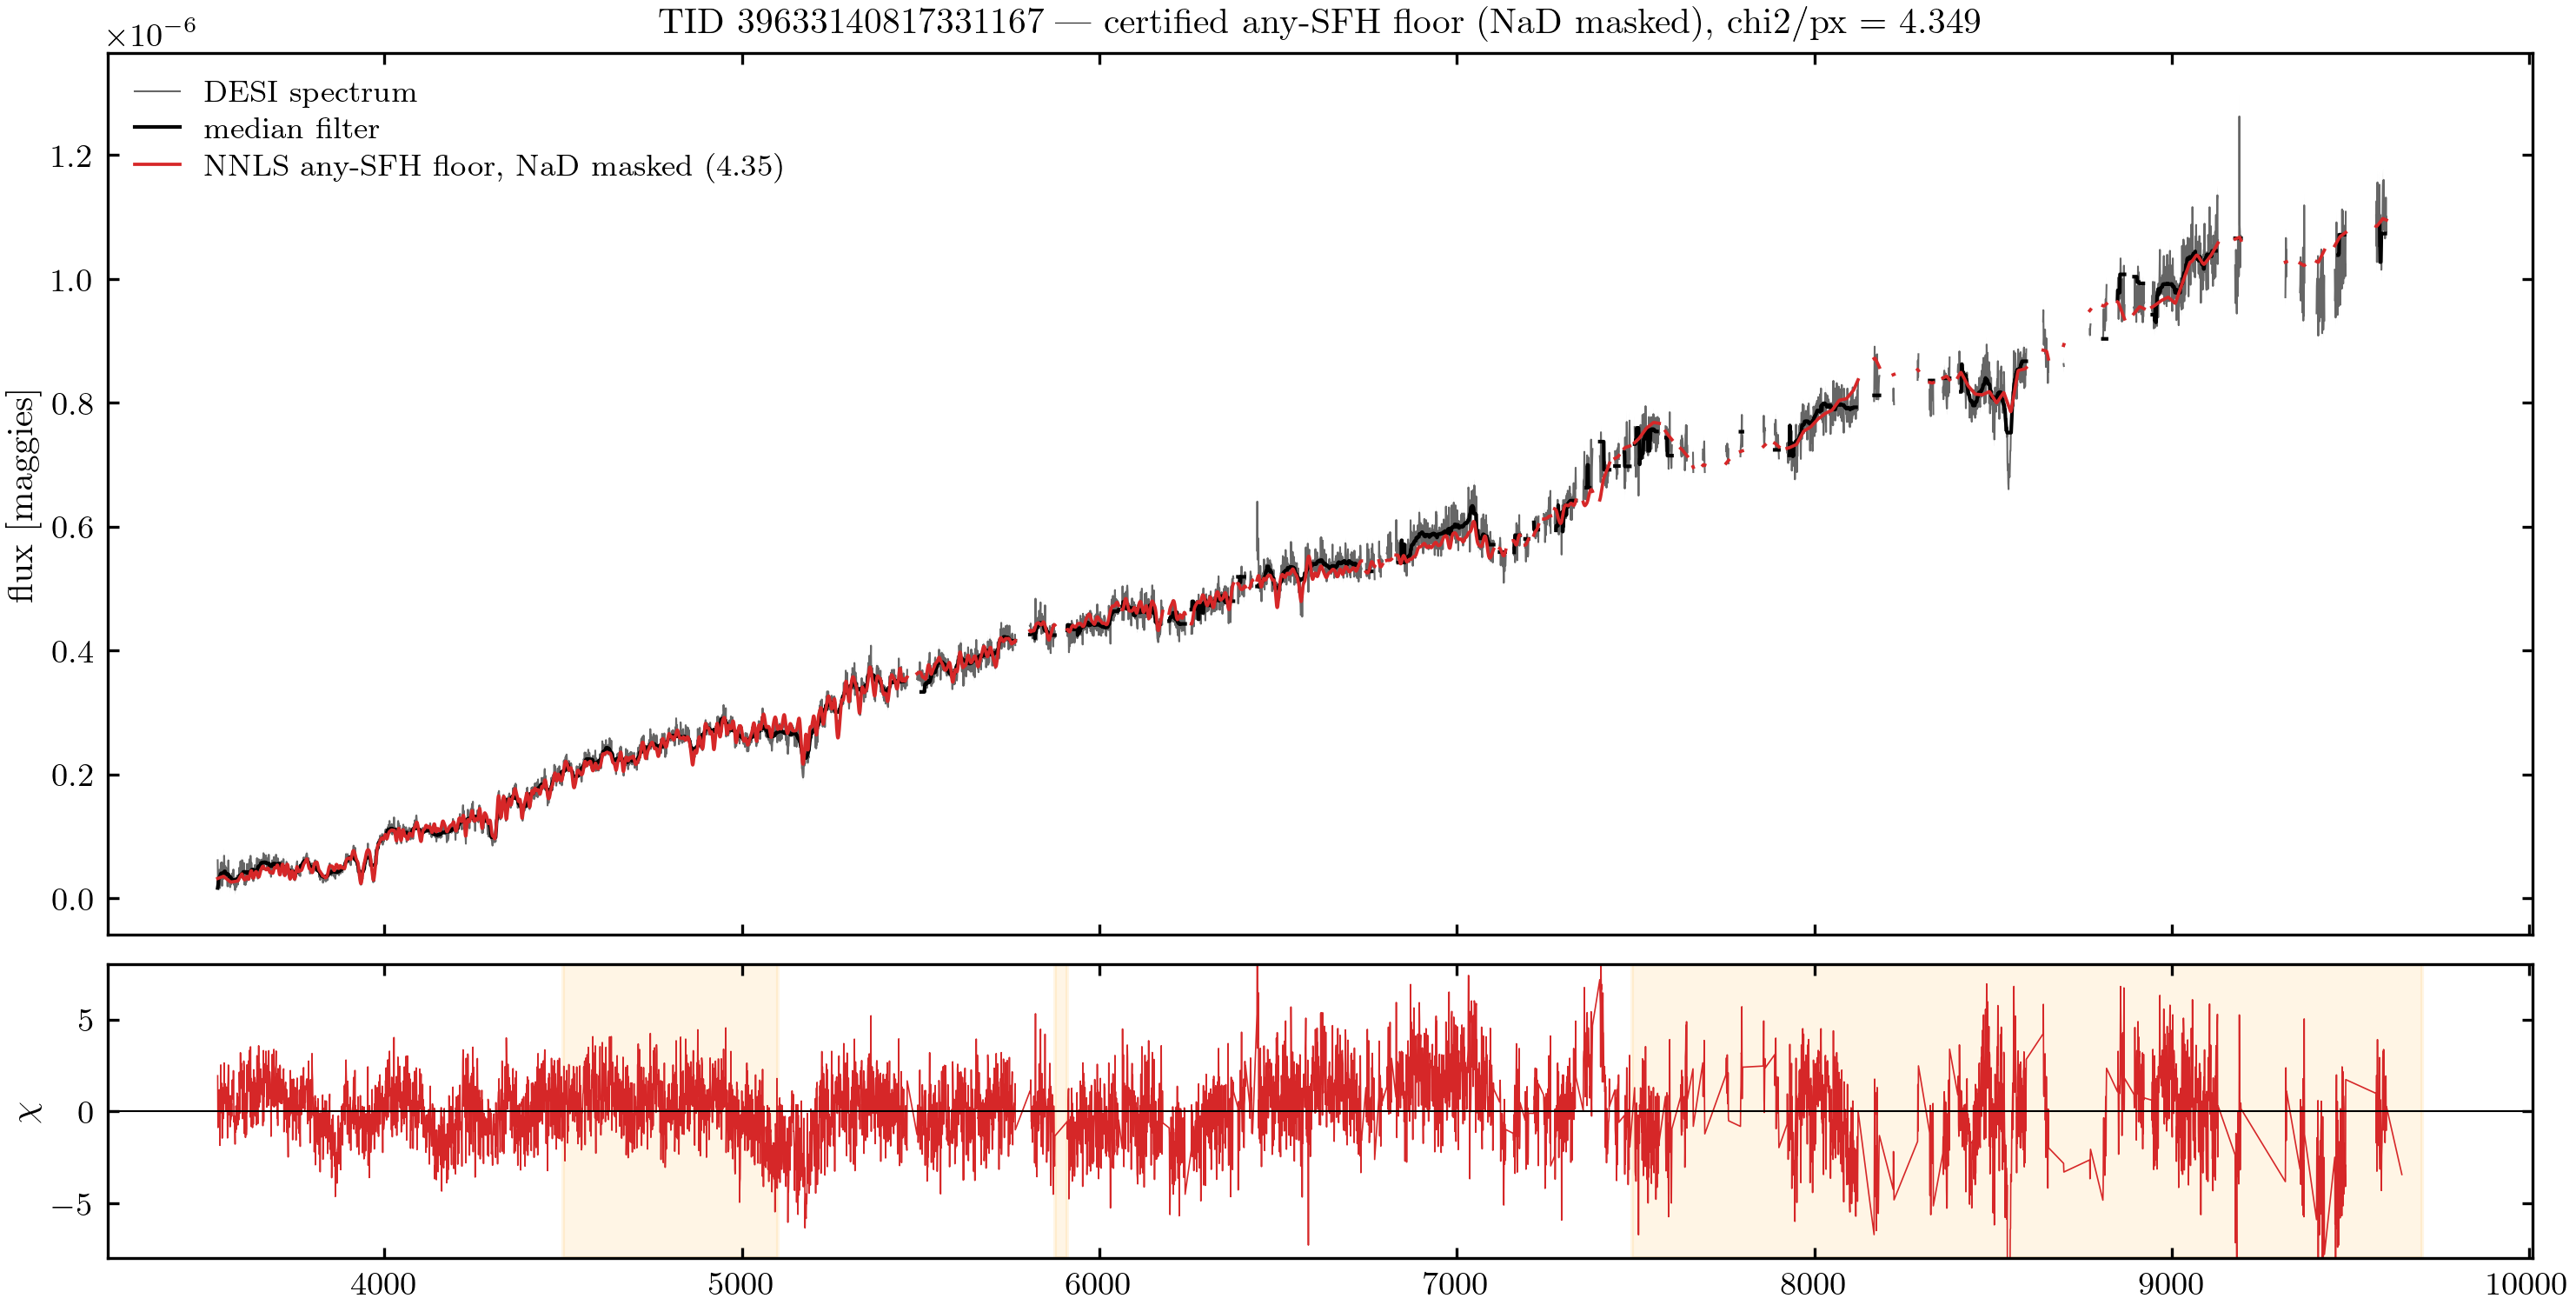

In [28]:
from scipy.signal import medfilt
from hubersed.plotting.spectra import spectrum_figure, residual_chi

spec_nnls = c2 @ basis                      # the certified-best model spectrum
wr = C.WAVE_OBS / (1 + z)
d  = np.where(m2, obs[0].flux, np.nan)
u  = np.where(m2, obs[0].uncertainty, np.nan)
mf = np.where(m2, medfilt(np.where(m2, obs[0].flux, np.nan), 31), np.nan)

fig, ax = spectrum_figure(C.WAVE_OBS, z=z, data=d, unc=u, medfilt=mf, band_kw={},
    models=[{"flux": np.where(m2, spec_nnls, np.nan),
             "label": "NNLS any-SFH floor, NaD masked (4.35)", "color": "C3", "lw": 0.9}],
    figsize=(12, 6))
chi = residual_chi(obs[0].flux, spec_nnls, obs[0].uncertainty, mask=m2)
ax[1].plot(wr[m2], chi[m2], lw=0.4, color="C3")
ax[1].axhline(0, c="k", lw=0.5); ax[1].set_ylim(-8, 8); ax[1].set_ylabel(r"$\chi$")
for x0, x1 in [(4500, 5100), (5876, 5910), (7490, 9700)]:
    ax[1].axvspan(x0, x1, color="orange", alpha=0.10)
ax[0].set_ylabel("flux [maggies]")
ax[0].set_title(f"TID {TID} — certified any-SFH floor (NaD masked), chi2/px = {rn2**2/m2.sum():.3f}")

mass fractions: [0.    0.    0.    0.    0.    0.    0.    0.032 0.417 0.551]


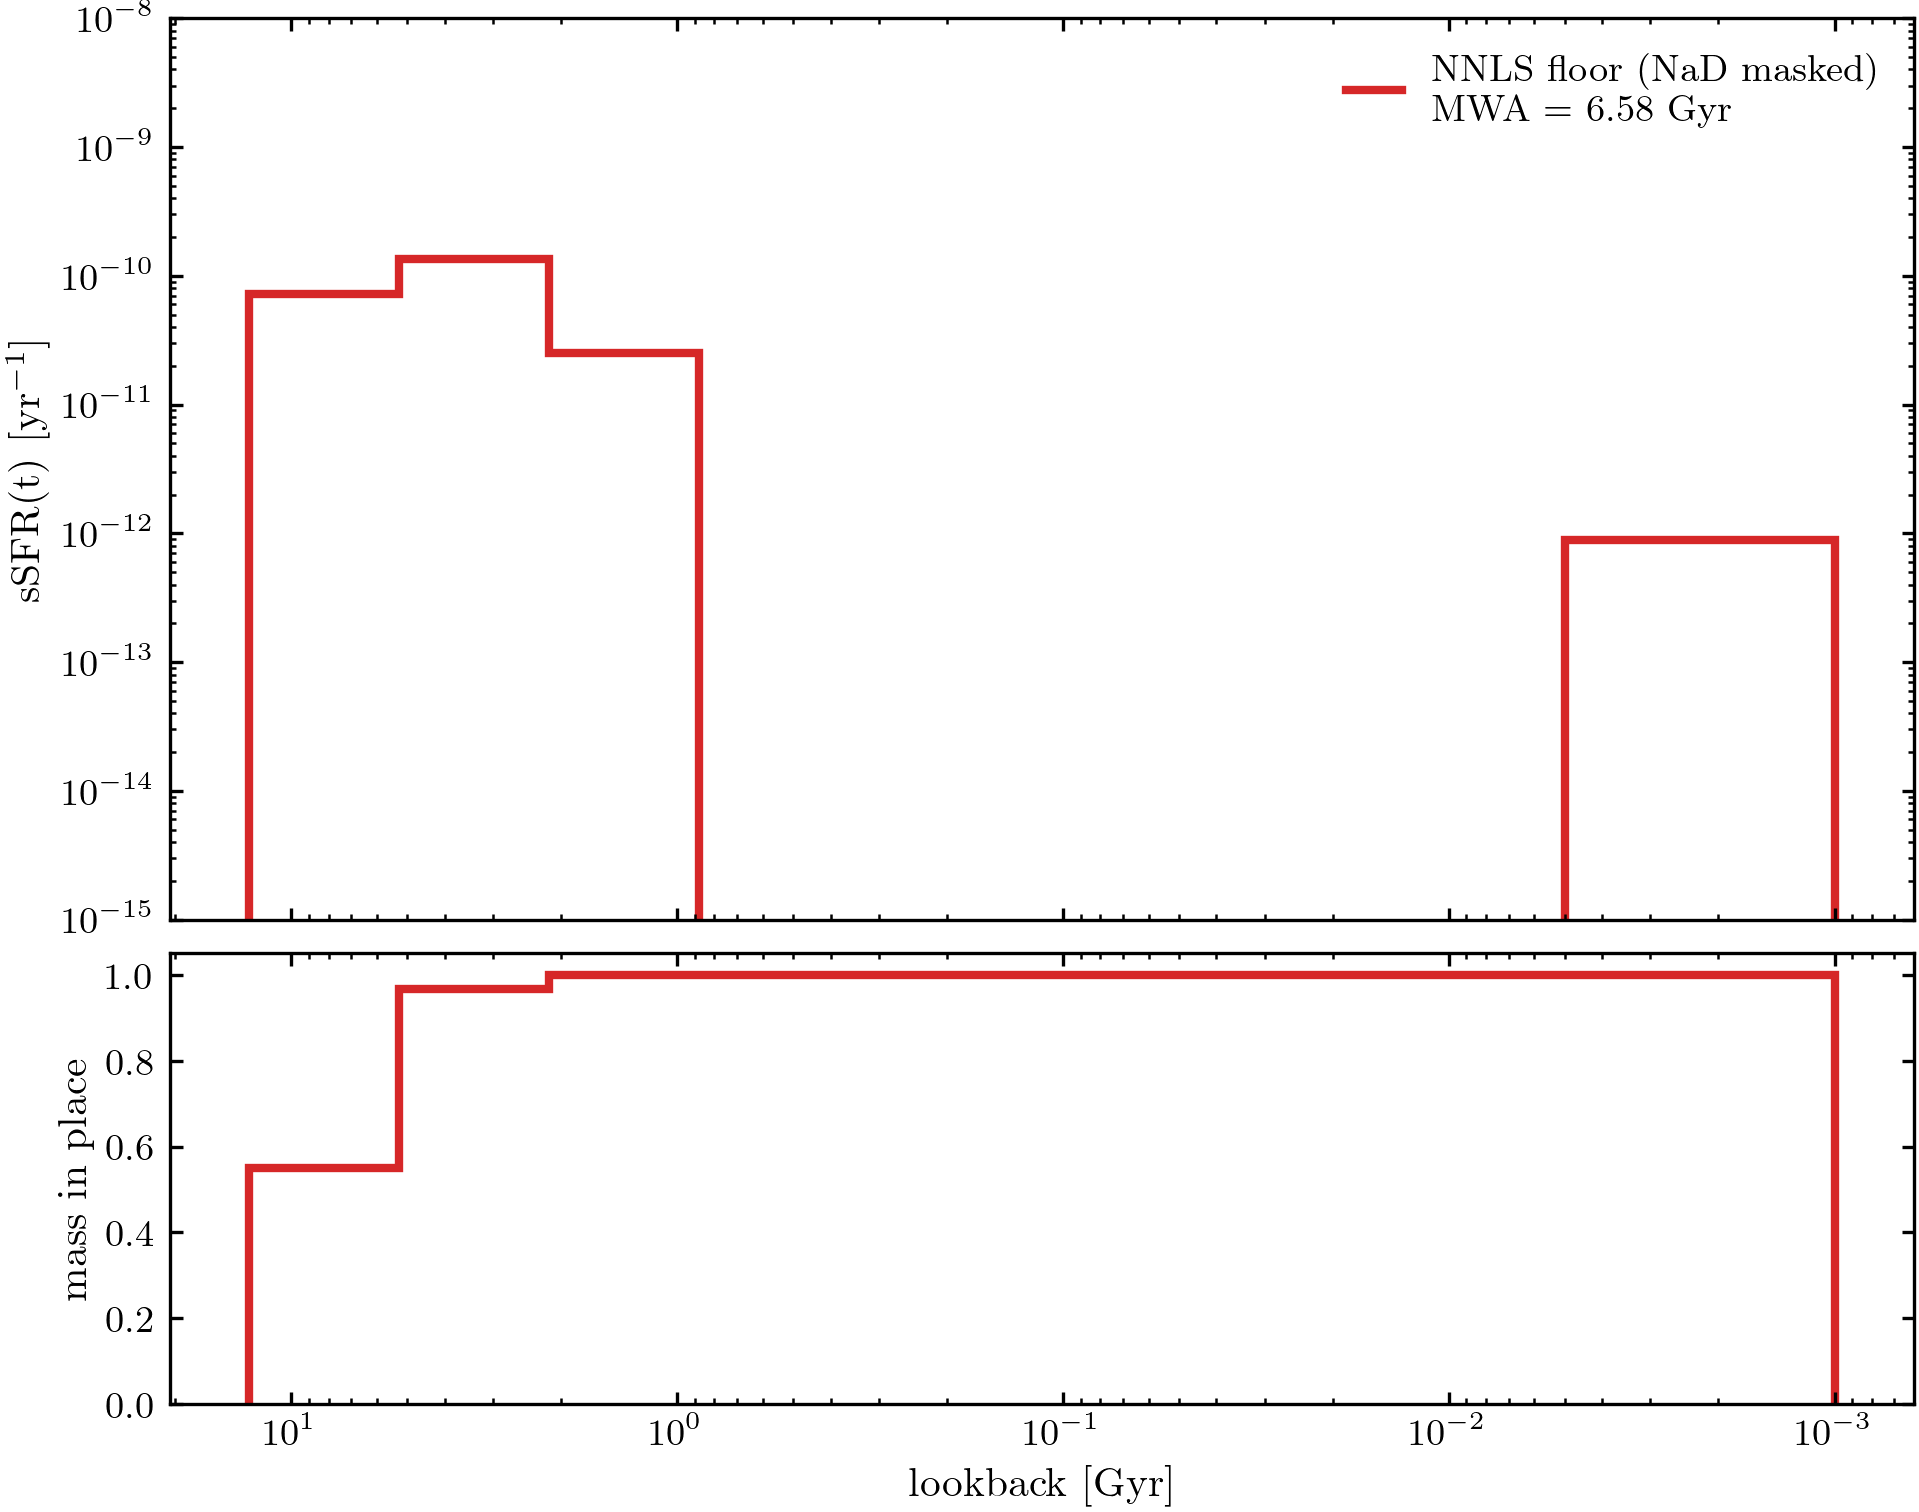

In [29]:
mfrac = c2 * 1e10 * 1  # relative; normalize below
mfrac = (c2 * 1e10) * 1.0
mb_n  = c2 / c2.sum() if c2.sum() > 0 else c2          # basis rows were equal-mass -> coeffs ∝ mass
sfr_n = mb_n * 1.0 / dt * np.sum(mb_n * dt)            # shape only; plot sSFR directly:
fig, axs = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})
ssfr = (mb_n / dt) / np.sum(mb_n)                       # per-yr, final-mass normalized
axs[0].stairs(np.maximum(ssfr, 1e-16), edges, color="C3", lw=2,
              label=f"NNLS floor (NaD masked)\nMWA = {np.sum(mb_n*bc):.2f} Gyr")
axs[0].set_xscale("log"); axs[0].set_yscale("log"); axs[0].set_ylim(1e-15, 1e-8)
axs[0].set_ylabel(r"sSFR(t) [yr$^{-1}$]"); axs[0].legend(fontsize=9)
axs[1].stairs(np.cumsum(mb_n[::-1])[::-1], edges, color="C3", lw=2)
axs[1].set_xscale("log"); axs[1].set_ylabel("mass in place"); axs[1].set_xlabel("lookback [Gyr]")
axs[0].invert_xaxis()
print("mass fractions:", np.round(mb_n, 3))

In [33]:
# full sky treatment: weak-OH +-3A (obs) + telluric absorption bands, then NNLS floor
skyf = "../.venv/lib/python3.13/site-packages/spender/data/sky-lines.txt"
import numpy as np
rows = [l.split() for l in open(skyf) if l.strip() and not l.startswith("#")]
wl   = np.array([float(r[0])*10 for r in rows]); I = np.array([float(r[1]) for r in rows])
weak = wl[(I >= 0.1) & (I < 2)]
oh   = np.min(np.abs(C.WAVE_OBS[:, None] - weak[None, :]), axis=1) < 3.0
tell = np.zeros_like(C.WAVE_OBS, bool)
for lo, hi in [(6860,6890),(7160,7330),(7590,7680),(8130,8350),(8950,9300)]:
    tell |= (C.WAVE_OBS >= lo) & (C.WAVE_OBS <= hi)
nad  = (C.WAVE_OBS/(1+z) >= 5876) & (C.WAVE_OBS/(1+z) <= 5910)
m3   = obs[0].mask & ~oh & ~tell & ~nad
A3 = (basis[:, m3] / obs[0].uncertainty[m3]).T
b3 = obs[0].flux[m3] / obs[0].uncertainty[m3]
c3_, rn3 = nnls(A3, b3)
print(f"certified any-SFH floor, full sky+NaD mask: chi2/px = {rn3**2/m3.sum():.3f}  (npix {m3.sum()})")

certified any-SFH floor, full sky+NaD mask: chi2/px = 4.042  (npix 4544)
